In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
pd.options.mode.chained_assignment = None 

import h5py as h5 
from astropy import units as u
from astropy import constants as c

import os
import scipy
from collections import Counter
from collections import defaultdict
import gc

from sklearn.utils import resample

pd.options.display.max_columns = None

In [2]:
import matplotlib.pyplot as plt
from matplotlib import rcParams
import matplotlib
from matplotlib.ticker import LogLocator, AutoMinorLocator, MultipleLocator
import matplotlib.ticker as ticker

fontparams = {
    "font.family": "serif",
    "mathtext.fontset" : "stix",
    "grid.color": "gray",
    "grid.linestyle": ":",
    "axes.titlesize": "18",
    "axes.labelsize": "16",
    "xtick.labelsize": "16",
    "ytick.labelsize": "16",
    "xtick.labelbottom": "True",
    "legend.framealpha": "1",
}
rcParams.update(fontparams) 

%config InlineBackend.figure_format='retina' # very useful command for high-res images

from cycler import cycler

colorPalette = {'red': "#E64D4E",
                'orange': "#EE9063",
                'yellow': "#FFDD7B",
                'green': "#77AC54",
                'blue': "#0B92B1",
                'violet': "#665191",
                'gray': "#B4B4B4"
}

custom_cycler = (cycler(color=[colorPalette['red'], colorPalette['blue'], colorPalette['green']]))


In [ ]:
pop_names = ['notides', 'realistic', 'perfect']
# pop_names = ['notides', 'realistic', 'perfect', 'z77']

pop_labels = {'notides': 'LEGACY',
              'realistic': 'KAPIL26',
              'perfect': 'PERFECT',
              'z77': 'Z77'
              }

pop_colors = {'notides': colorPalette['red'],
              'realistic': colorPalette['blue'],
              'perfect': colorPalette['green'],
              'z77': colorPalette['orange']}

pop_cmaps = {'notides': 'Reds',
              'realistic': 'Blues',
              'perfect': 'Greens',
              'z77': 'Oranges'}

dco_types = ['BBH', 'BHNS', 'BNS']
dco_st = [28, 27, 26]
mt_labels = [
    "No MT", "Stable MT 1→2", "Stable MT 2→1", 
    "CE_Primary", "CE_Secondary", "CE_Both", "MT to Merger"
]
branching_labels = {1: 'Primary', 2: 'Secondary', 3: 'Both', 4: 'MT_to_Merger'}

plot_path = 'pop_plots/'

data_path = 'data_files/'

In [5]:
pop_dfs = {}
for pop_name in pop_names:
    pop_dfs[pop_name] = pd.read_csv(data_path + pop_name+'_spin_df.csv') 

# Figure 1

In [ ]:
total_binaries = np.round(np.max(pop_dfs['realistic']['SEED'])/480000) * 480000

# Known values from simulations:
m1_tot = 52288524.37805214
m2_tot = 27764188.067921326

If not known, (m1_tot + m2_tot) can be estimated as total_binaries * 20.85 M_sun

m2_tot $\approx$ m1_tot / 2 

In [11]:
print(m1_tot, m2_tot, m1_tot + m2_tot)
m_per_sim = (m1_tot + m2_tot) / total_binaries
print(f"Mass per simulation: {m_per_sim:.2f} Msun")

52288524.37805214 27764188.067921326 80052712.44597346
Mass per simulation: 20.85 Msun


In [12]:
import scipy.integrate as integrate

def kroupa(m):
    m = np.asarray(m, float)
    return np.where(m < 0.08, m**-0.3,
           np.where(m < 0.50, 0.08 * m**-1.3,
                               0.04 * m**-2.3))
mass_sampled_integral = integrate.quad(lambda m: m * kroupa(m), 5, 150)[0]
mass_true_integral = integrate.quad(lambda m: m * kroupa(m), 0.08, 150)[0]
f_M = mass_sampled_integral / mass_true_integral
M_true = (m1_tot + m2_tot) / f_M

print(f"Total mass represented by the simulations: {M_true:.2e} Msun")
print(f"Mass represented per simulation: {M_true / total_binaries:.2f} Msun")

Total mass represented by the simulations: 2.82e+08 Msun
Mass represented per simulation: 73.44 Msun


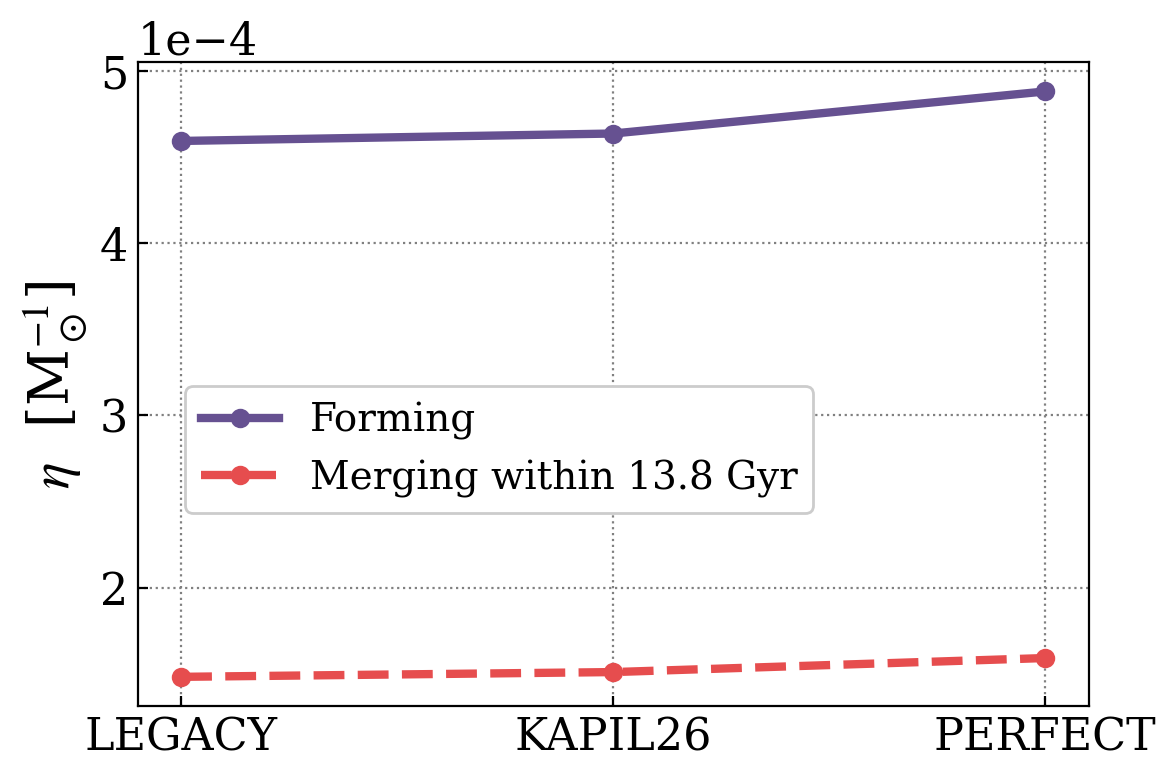

In [13]:
fig, ax = plt.subplots(ncols=1, nrows=1, figsize=(6, 4))

pop_labels_list = [pop_labels[pop_name] for pop_name in pop_names]
n_formation = [np.sum(pop_dfs[pop_name]['BBH']) for pop_name in pop_names]
n_merger = [np.sum(pop_dfs[pop_name]['BBH'] & pop_dfs[pop_name]['Merges_Hubble_Time']) for pop_name in pop_names]

# ax = axes[0]
ax.plot(pop_labels_list, [n_formation[i] / M_true for i in range(len(n_formation))], lw=3, ls='-', marker='o', color=colorPalette['violet'], label='Forming')
ax.plot(pop_labels_list, [n_merger[i] / M_true for i in range(len(n_merger))], lw=3, ls='--', marker='o', color=colorPalette['red'], label='Merging within 13.8 Gyr')

# ax.set_ylim(0.75e-5, 3.65e-5)

# ax.set_title('BBH')
ax.set_ylabel("$\\eta$  [M$_\\odot^{-1}$]", fontsize=20)
ax.ticklabel_format(axis='y', style='sci', scilimits=(0, 0))
ax.tick_params(axis='both', direction='in')
ax.legend(fontsize=14, loc=(0.05, 0.3))
ax.grid()


plt.tight_layout()
# plt.savefig(plot_path+'bbh_rates.pdf', dpi=300, bbox_inches='tight')
plt.show()
    

# Formation and Merger Rates by Channel

In [14]:
dco_type='BBH'

for pop_name in pop_names:
    pop_df = pop_dfs[pop_name][(pop_dfs[pop_name][dco_type])]

    any_rlof = (pop_df['RLOF_Primary']==True) + (pop_df['RLOF_Secondary']==True) + (pop_df['RLOF_Both']==True)
    any_ce = (pop_df['CE_Primary']==True) + (pop_df['CE_Secondary']==True) +(pop_df['CE_Both']==True)
    any_che = (pop_df['CH_on_MS(1)']==True) + (pop_df['CH_on_MS(2)']==True)
    n_ce_all = np.sum(any_ce * (~any_che))
    n_smt_all = np.sum(any_rlof * (~any_ce) * (~any_che))
    n_che_all = np.sum(any_che)


    pop_df = pop_dfs[pop_name][(pop_dfs[pop_name][dco_type]) & (pop_dfs[pop_name]['Merges_Hubble_Time'])]

    any_rlof = (pop_df['RLOF_Primary']==True) + (pop_df['RLOF_Secondary']==True) + (pop_df['RLOF_Both']==True)
    any_ce = (pop_df['CE_Primary']==True) + (pop_df['CE_Secondary']==True) +(pop_df['CE_Both']==True)
    any_che = (pop_df['CH_on_MS(1)']==True) + (pop_df['CH_on_MS(2)']==True)
    ce = any_ce * (~any_che)
    smt = any_rlof * (~any_ce) * (~any_che)
    che = any_che

    m1 = pop_df['M_max@DCO']
    m2 = pop_df['M_min@DCO']

    print(f"{pop_name} CE: {ce.sum()} ({100 * ce.sum()/len(pop_df):.2f}%), SMT Only: {smt.sum()} ({100 * smt.sum()/len(pop_df):.2f}%), CHE: {che.sum()} ({100 * che.sum()/len(pop_df):.2f}%)")
    print(f"CE Merger efficiency: {100 * ce.sum()/n_ce_all:.2f}%, SMT Merger efficiency: {100 * smt.sum()/n_smt_all:.2f}%, CHE Merger efficiency: {100 * che.sum()/n_che_all:.2f}%")
    print(f"Median q: CE: {np.median(m2[ce]/m1[ce]):.2f}, SMT: {np.median(m2[smt]/m1[smt]):.2f}, CHE: {np.median(m2[che]/m1[che]):.2f}")
    print()

notides CE: 22229 (53.16%), SMT Only: 18329 (43.84%), CHE: 1255 (3.00%)
CE Merger efficiency: 92.06%, SMT Merger efficiency: 17.60%, CHE Merger efficiency: 98.35%
Median q: CE: 0.70, SMT: 0.69, CHE: 1.00

realistic CE: 22193 (52.11%), SMT Only: 19561 (45.93%), CHE: 838 (1.97%)
CE Merger efficiency: 92.44%, SMT Merger efficiency: 18.48%, CHE Merger efficiency: 96.32%
Median q: CE: 0.69, SMT: 0.68, CHE: 1.00

perfect CE: 25020 (55.74%), SMT Only: 18614 (41.46%), CHE: 1257 (2.80%)
CE Merger efficiency: 91.38%, SMT Merger efficiency: 17.08%, CHE Merger efficiency: 98.36%
Median q: CE: 0.70, SMT: 0.68, CHE: 1.00



In [15]:
branching_ratios = defaultdict(dict)
print("Mergers")
for pop_name in pop_names:
    print(f"Processing: {pop_labels[pop_name]}")
    for i, dco_type in enumerate(dco_types):
        pop_df = pop_dfs[pop_name][(pop_dfs[pop_name]['Stellar_Type(1)'] + pop_dfs[pop_name]['Stellar_Type(2)'] == dco_st[i])]
        pop_df = pop_df[pop_df['Merges_Hubble_Time']==True]
        
        any_rlof = (pop_df['RLOF_Primary']==True) + (pop_df['RLOF_Secondary']==True) + (pop_df['RLOF_Both']==True)
        any_ce = (pop_df['CE_Primary']==True) + (pop_df['CE_Secondary']==True) +(pop_df['CE_Both']==True)
        any_che = (pop_df['CH_on_MS(1)']==True) + (pop_df['CH_on_MS(2)']==True)

        ce_primary_only = (pop_df['CE_Primary']==True) * (pop_df['CE_Secondary']==False) * (pop_df['CE_Both']==False)
        ce_secondary_only = (pop_df['CE_Primary']==False) * (pop_df['CE_Secondary']==True) * (pop_df['CE_Both']==False)
        ce_both = ((pop_df['CE_Primary']==True) * (pop_df['CE_Secondary']==True)) + (pop_df['CE_Both']==True)
        
        smt = any_rlof * (~any_ce) * (~any_che)
        smt_primary_only = smt * (pop_df['RLOF_Primary']==True) * (pop_df['RLOF_Secondary']==False) * (pop_df['RLOF_Both']==False)
        smt_secondary_only = smt * (pop_df['RLOF_Primary']==False) * (pop_df['RLOF_Secondary']==True) * (pop_df['RLOF_Both']==False)
        smt_both = smt * (((pop_df['RLOF_Primary']==True) * (pop_df['RLOF_Secondary']==True)) + pop_df['RLOF_Both'])
        
        che = any_che * any_rlof


        # Print Results
        print(f"ALL {dco_type}s: {len(pop_df)}")
        print(f"{dco_type}s with RLOF: {np.sum(any_rlof)}")
        print(f"→ {dco_type}s with Stable Mass Transfer: {(np.sum(smt))}")
        print(f"    →→ Primary Only: {np.sum(smt_primary_only)}")
        print(f"    →→ Secondary Only: {(np.sum(smt_secondary_only))}")
        print(f"    →→ Both: {(np.sum(smt_both))}")
        print(f"→ {dco_type}s with Common Envelope: {(np.sum(any_ce))}")
        print(f"    →→ Primary Only: {np.sum(ce_primary_only)}")
        print(f"    →→ Secondary Only: {np.sum(ce_secondary_only)}")
        print(f"    →→ Both: {np.sum(ce_both)}")
        print(f"→ {dco_type}s with Chemically Homogeneous Evolution: {(np.sum(che))}")
        print(f"{dco_type}s with No Mass Transfer: {np.sum(~any_rlof)}")
        print()

        branching_ratios[pop_name][dco_type] = {
            "Total": len(pop_df),
            "No MT": np.sum(~any_rlof),
            "SMT": np.sum(smt),
            "CE": np.sum(any_ce),
            "Mass Transfer": {
                "Stable (RLOF)": {
                    "Primary": np.sum(smt_primary_only),
                    "Secondary": np.sum(smt_secondary_only),
                    "Both": np.sum(smt_both)
                },
                "Unstable (CE)": {
                    "Primary": np.sum(ce_primary_only),
                    "Secondary": np.sum(ce_secondary_only),
                    "Both": np.sum(ce_both)
                },
                "CHE" : np.sum(che)
            }
        }
        

Mergers
Processing: LEGACY
ALL BBHs: 41813
BBHs with RLOF: 41813
→ BBHs with Stable Mass Transfer: 18329
    →→ Primary Only: 0
    →→ Secondary Only: 0
    →→ Both: 18329
→ BBHs with Common Envelope: 22229
    →→ Primary Only: 0
    →→ Secondary Only: 22225
    →→ Both: 4
→ BBHs with Chemically Homogeneous Evolution: 1255
BBHs with No Mass Transfer: 0

ALL BHNSs: 4632
BHNSs with RLOF: 4632
→ BHNSs with Stable Mass Transfer: 369
    →→ Primary Only: 0
    →→ Secondary Only: 0
    →→ Both: 369
→ BHNSs with Common Envelope: 4263
    →→ Primary Only: 2
    →→ Secondary Only: 4252
    →→ Both: 9
→ BHNSs with Chemically Homogeneous Evolution: 0
BHNSs with No Mass Transfer: 0

ALL BNSs: 1066
BNSs with RLOF: 1066
→ BNSs with Stable Mass Transfer: 1
    →→ Primary Only: 0
    →→ Secondary Only: 0
    →→ Both: 1
→ BNSs with Common Envelope: 1065
    →→ Primary Only: 4
    →→ Secondary Only: 996
    →→ Both: 65
→ BNSs with Chemically Homogeneous Evolution: 0
BNSs with No Mass Transfer: 0

Proces

# Figure 2

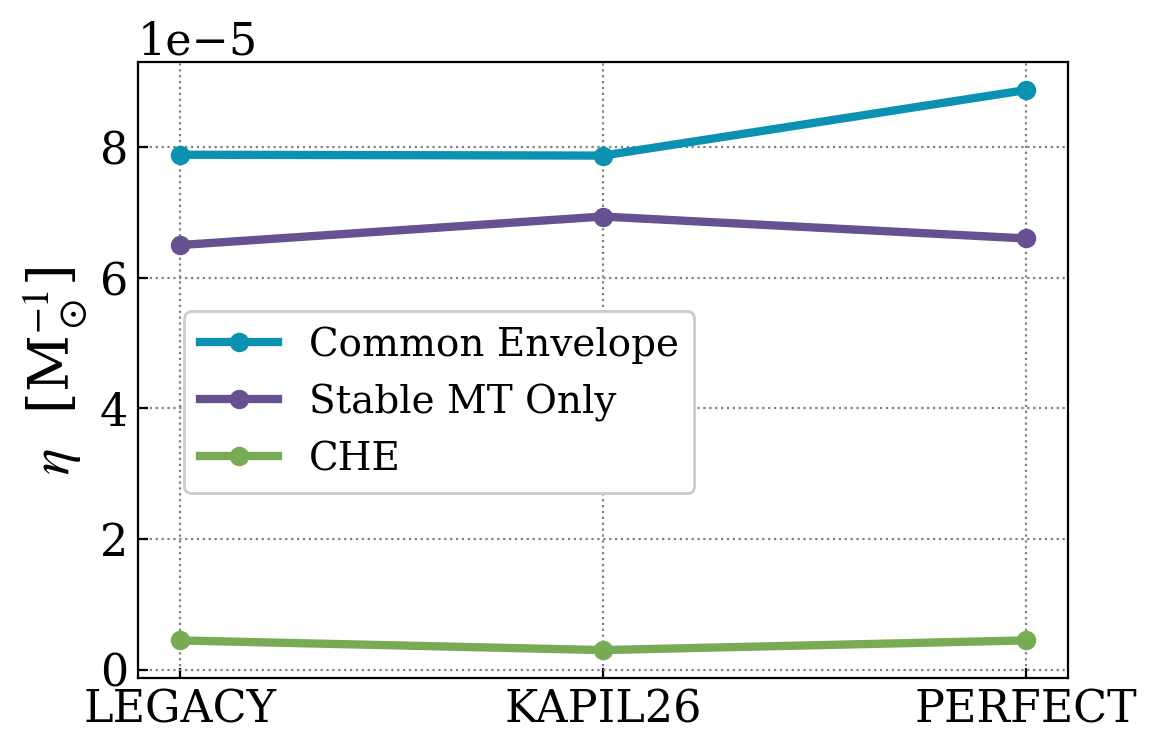

In [16]:
# Given color and label mappings
colors = {
    "CE": colorPalette['blue'],
    "SMT": colorPalette['violet'],
    "CHE" : colorPalette['green']
}

labels = {
    "Total": "Total DCOs",
    "No MT": "No Mass Transfer",
    "SMT": "Stable MT Only",
    "CE": "Common Envelope",
    "CHE" : "CHE"
}

# Extract data
# dco_types = list(branching_ratios[pop_names[0]].keys())
dco_linestyles = {"BBH": "-", "BHNS": "-.", "BNS": ':'}

def kroupa(m):
    m = np.asarray(m, float)
    return np.where(m < 0.08, m**-0.3,
           np.where(m < 0.50, 0.08 * m**-1.3,
                               0.04 * m**-2.3))
mass_sampled_integral = integrate.quad(lambda m: m * kroupa(m), 5, 150)[0]
mass_true_integral = integrate.quad(lambda m: m * kroupa(m), 0.08, 150)[0]
f_M = mass_sampled_integral / mass_true_integral
M_true = (m1_tot + m2_tot) / f_M


fig, ax = plt.subplots(ncols=1, figsize=(6, 4))

dco_type='BBH'
# Initialize storage for plotting
data = {key: [] for key in labels.keys()}

# Collect data across populations
for pop_name in pop_names:
    data["Total"].append(branching_ratios[pop_name][dco_type]["Total"])
    data["No MT"].append(branching_ratios[pop_name][dco_type]["No MT"])
    data["SMT"].append(branching_ratios[pop_name][dco_type]["SMT"])
    data["CE"].append(branching_ratios[pop_name][dco_type]["CE"])
    data["CHE"].append(branching_ratios[pop_name][dco_type]["Mass Transfer"]["CHE"])


# # # Normalize by total number of DCOs per population
# # totals = np.ones_like(np.array([data["Total"]]))
# # for key in data.keys():
# #     data[key] = np.array(data[key]) / totals

# Normalize by total Star forming mass
for key in data.keys():
    data[key] = np.array(data[key]) / M_true


for key in colors.keys():
    ax.plot([pop_labels[val] for val in pop_names], data[key], label=labels[key], color=colors[key], marker="o", linewidth=3)

# ax.set_ylim(0.8e-7, 6.85e-6)

ax.set_ylabel("$\\eta$  [M$_\\odot^{-1}$]", fontsize=20)
ax.ticklabel_format(axis='y', style='sci', scilimits=(0, 0))
ax.tick_params(axis='both', direction='in')
ax.legend(fontsize=14, loc=(0.05, 0.3))
ax.grid()

# plt.savefig(plot_path + "bbh_mergers_by_formation_channel.pdf", dpi=300, bbox_inches='tight')
plt.show()


# Manual simulation to verify that yield rates are reasonable

In [ ]:
from scipy.integrate import cumtrapz

# 1. Use a logarithmic grid to properly capture the power-law shape
x = np.geomspace(5, 150.0, 100000)

# 2. Evaluate the PDF
y = kroupa(x)

# 3. Use trapezoidal integration for a more accurate CDF
# cumtrapz returns an array of length N-1, so we prepend a 0 
# to match the length of x
kroupa_cdf = cumtrapz(y, x, initial=0)

# 4. Normalize
kroupa_cdf /= kroupa_cdf[-1]

N_SAMPLES = 3.8e6
# 5. Sample and interpolate
y_samples = np.random.uniform(0, 1, size=int(N_SAMPLES))
m1_samples = np.interp(y_samples, kroupa_cdf, x)
q_samples = np.random.uniform(0.01, 1, size=int(N_SAMPLES))
m2_samples = q_samples * m1_samples

In [ ]:
print(f"Total mass of sampled binaries: {np.sum(m1_samples) + np.sum(m2_samples):.2f} Msun")
print(f"Average mass per binary: {(np.sum(m1_samples) + np.sum(m2_samples)) / N_SAMPLES:.2f} Msun")
print(f"Approximate BBH yield per Msun: {np.sum((m1_samples > 15) & (m2_samples > 15)) / (np.sum(m1_samples) + np.sum(m2_samples)):.4e} BBH/Msun")

print(f"Simulated BBH yield per Msun: {np.sum(pop_dfs['realistic']['BBH']) / (np.sum(m1_samples) + np.sum(m2_samples)):.4e} Formed BBH/Msun")
print(f"Simulated BBH merger yield per Msun: {np.sum(pop_dfs['realistic']['BBH'] & pop_dfs['realistic']['Merges_Hubble_Time']) / (np.sum(m1_samples) + np.sum(m2_samples)):.4e} Merging BBH/Msun")

Total mass of sampled binaries: 80169130.08 Msun
Average mass per binary: 21.10 Msun
Approximate BBH yield per Msun: 4.5019e-03 BBH/Msun
Simulated BBH yield per Msun: 1.6309e-03 Formed BBH/Msun
Simulated BBH merger yield per Msun: 5.3128e-04 Merging BBH/Msun


In [ ]:
mass_sampled_integral = integrate.quad(lambda m: m * kroupa(m), 5, 150)[0]
mass_true_integral = integrate.quad(lambda m: m * kroupa(m), 0.08, 150)[0]
f_M = mass_sampled_integral / mass_true_integral

M_sim_sampled = np.sum(m1_samples) + np.sum(m2_samples)
M_true = M_sim_sampled / f_M

N_BBH = np.sum(pop_dfs['realistic']['BBH'])

normalized_yield = N_BBH / M_true

print(f"{normalized_yield:.3e}")

4.630e-04


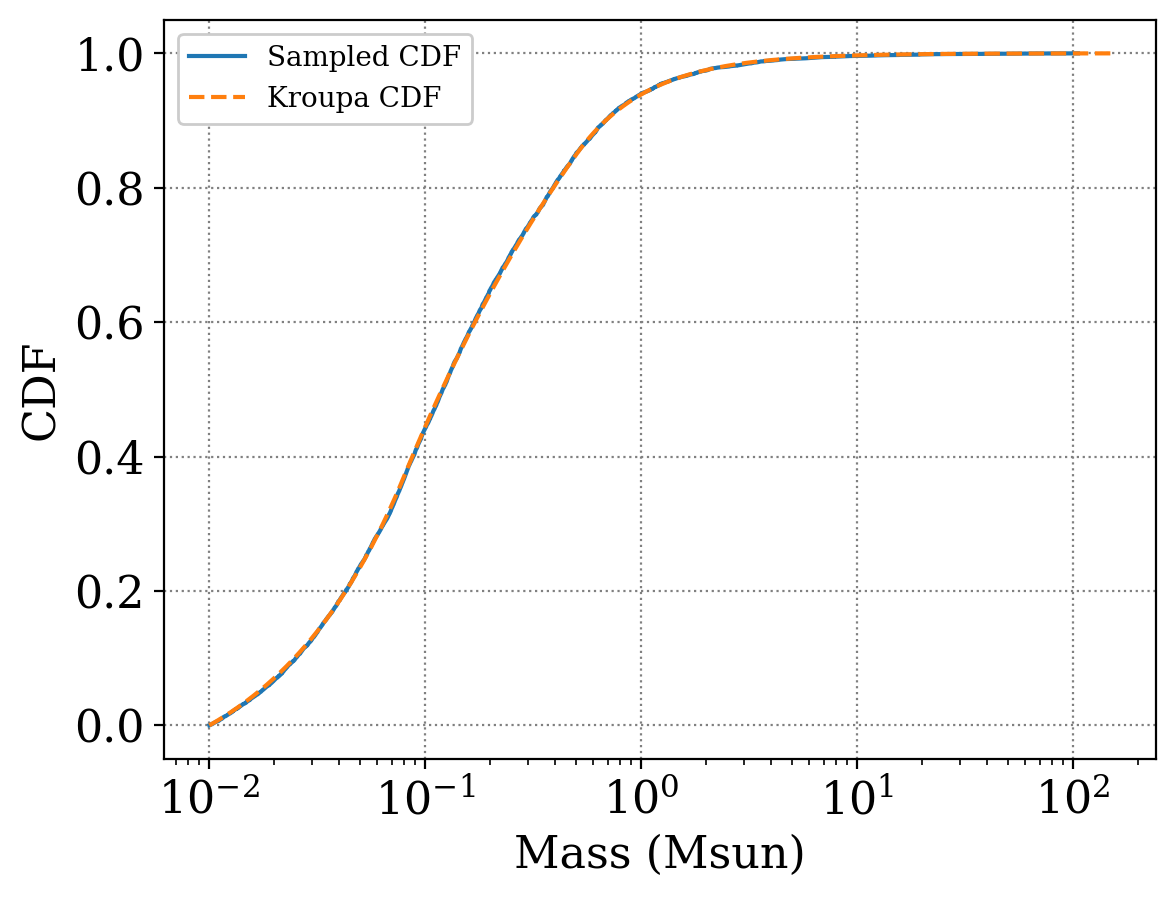

In [ ]:
sorted_m1 = np.sort(m1_samples)
cdf_m1 = np.arange(1, len(sorted_m1)+1) / len(sorted_m1)
plt.plot(sorted_m1, cdf_m1, label='Sampled CDF')
plt.plot(x, kroupa_cdf, ls='--', label='Kroupa CDF')
plt.xscale('log')
plt.xlabel('Mass (Msun)')
plt.ylabel('CDF')
plt.legend()
plt.grid()
plt.show()

In [ ]:
# 1. Use a logarithmic grid to properly capture the power-law shape
x_full = np.geomspace(0.08, 150.0, 100000)

# 2. Evaluate the PDF
y = kroupa(x_full)

# 3. Use trapezoidal integration for a more accurate CDF
# cumtrapz returns an array of length N-1, so we prepend a 0 
# to match the length of x
kroupa_cdf = cumtrapz(y, x_full, initial=0)

# 4. Normalize
kroupa_cdf /= kroupa_cdf[-1]

N_SAMPLES = 3.8e6
# 5. Sample and interpolate
y_samples = np.random.uniform(0, 1, size=int(N_SAMPLES))
m1_samples_full = np.interp(y_samples, kroupa_cdf, x_full)
q_samples = np.random.uniform(0.01, 1, size=int(N_SAMPLES))
m2_samples_full = q_samples * m1_samples_full

In [ ]:
print(f"Total mass of binaries in full distribution: {np.sum(m1_samples_full) + np.sum(m2_samples_full):.2f} Msun")
print(f"Average mass per binary in full distribution: {(np.sum(m1_samples_full) + np.sum(m2_samples_full)) / N_SAMPLES:.2f} Msun")
print(f"Correction factor for sampling above 5 Msun: {(np.sum(m1_samples) + np.sum(m2_samples)) / (np.sum(m1_samples_full) + np.sum(m2_samples_full)):.4f}")
print()
print(f"Approximate BBH yield per Msun in full distribution: {np.sum((m1_samples_full > 15) & (m2_samples_full > 15)) / (np.sum(m1_samples_full) + np.sum(m2_samples_full)):.4e} BBH/Msun")

print(f"Simulated BBH yield per Msun: {np.sum(pop_dfs['realistic']['BBH']) / (np.sum(m1_samples_full) + np.sum(m2_samples_full)):.4e} Formed BBH/Msun")
print(f"Simulated BBH merger yield per Msun: {np.sum(pop_dfs['realistic']['BBH'] & pop_dfs['realistic']['Merges_Hubble_Time']) / (np.sum(m1_samples_full) + np.sum(m2_samples_full)):.4e} Merging BBH/Msun")

Total mass of binaries in full distribution: 3364921.22 Msun
Average mass per binary in full distribution: 0.89 Msun
Correction factor for sampling above 5 Msun: 23.8250

Approximate BBH yield per Msun in full distribution: 1.3162e-03 BBH/Msun
Simulated BBH yield per Msun: 3.8857e-02 Formed BBH/Msun
Simulated BBH merger yield per Msun: 1.2658e-02 Merging BBH/Msun


# Other Plots

## Mass Spectrum by Formation Channel

In [19]:

pop_name = 'realistic'
# pop_name = 'perfect'
dco_type = 'BBH'
pop_df = pop_dfs[pop_name]
pop_df = pop_df[pop_df[dco_type] & pop_df['Merges_Hubble_Time']]

x1 = pop_df['Mass@DCO(1)']
x2 = pop_df['Mass@DCO(2)']

x1 = pop_df['M_max@DCO']
x2 = pop_df['M_min@DCO']

mass_ratio_flip_mask = pop_df['Mass@DCO(1)'] != pop_df['M_max@DCO']
fb1 = pop_df['fallback_1']
fb2 = pop_df['fallback_1']

fb_max = fb1
fb_max[mass_ratio_flip_mask] = fb2[mass_ratio_flip_mask]

fb_min = fb2
fb_min[mass_ratio_flip_mask] = fb1[mass_ratio_flip_mask]

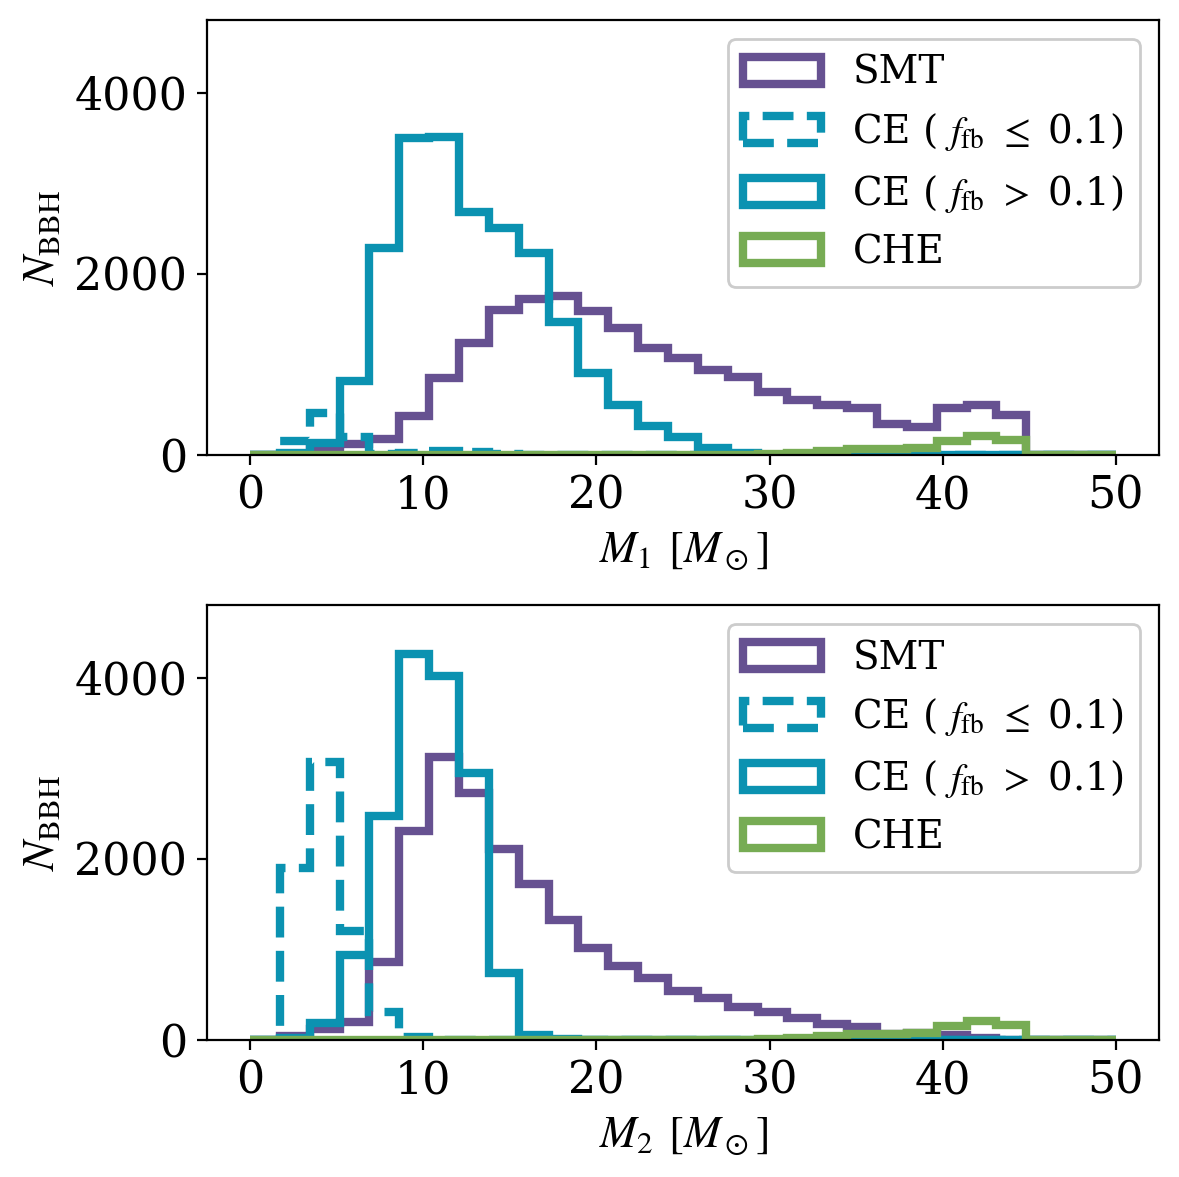

In [23]:
fig, axes = plt.subplots(ncols=1, nrows=2, figsize=(6, 6), sharex=False)

pop_name = 'realistic'
# pop_name = 'perfect'
dco_type = 'BBH'
pop_df = pop_dfs[pop_name]
pop_df = pop_df[pop_df[dco_type] & pop_df['Merges_Hubble_Time']]

x1 = pop_df['Mass@DCO(1)']
x2 = pop_df['Mass@DCO(2)']

x1 = pop_df['M_max@DCO']
x2 = pop_df['M_min@DCO']

mass_ratio_flip_mask = pop_df['Mass@DCO(1)'] != pop_df['M_max@DCO']
fb1 = pop_df['fallback_1']
fb2 = pop_df['fallback_2']

fb_max = fb1
fb_max[mass_ratio_flip_mask] = fb2[mass_ratio_flip_mask]

fb_min = fb2
fb_min[mass_ratio_flip_mask] = fb1[mass_ratio_flip_mask]

bins_x = np.linspace(0, 50, 30)

for i, x in enumerate([x1, x2]):
    ax = axes[i]

    if i==0:
        fb_mask = fb_max < 0.1
    else:
        fb_mask = fb_min < 0.1
    
    any_rlof = (pop_df['RLOF_Primary']==True) + (pop_df['RLOF_Secondary']==True) + (pop_df['RLOF_Both']==True)
    any_ce = (pop_df['CE_Primary']==True) + (pop_df['CE_Secondary']==True) +(pop_df['CE_Both']==True)
    any_che = (pop_df['CH_on_MS(1)']==True) + (pop_df['CH_on_MS(2)']==True)
    smt_mask = any_rlof * (~any_ce) * (~any_che)
    ce_mask = any_ce * (~any_che)

    ax.hist(x[smt_mask], bins=bins_x, density=False, histtype='step', lw=3, color=colorPalette['violet'], label=r'SMT')
    ax.hist(x[fb_mask & ce_mask], bins=bins_x, density=False, histtype='step', lw=3, color=colorPalette['blue'], ls='--', label=r'CE ( $f_{\rm fb}$ $\leq$ 0.1)')
    ax.hist(x[~fb_mask & ce_mask], bins=bins_x, density=False, histtype='step', lw=3, color=colorPalette['blue'], label=r'CE ( $f_{\rm fb}$ $>$ 0.1)')
    ax.hist(x[any_che], bins=bins_x, density=False, histtype='step', lw=3, color=colorPalette['green'], label=r'CHE')

    ax.legend(fontsize=14)
    ax.set_ylabel(r'$N_{\rm BBH}$')
    ax.set_ylim(0, 4800)

axes[0].set_xlabel('$M_1$ $[M_\odot]$')
axes[1].set_xlabel('$M_2$ $[M_\odot]$')

plt.tight_layout()
# plt.savefig(plot_path+"m1_m2_breakdown_realistic.pdf", dpi=300, bbox_inches='tight')

plt.show()

## Mass ratio by Formation Channel

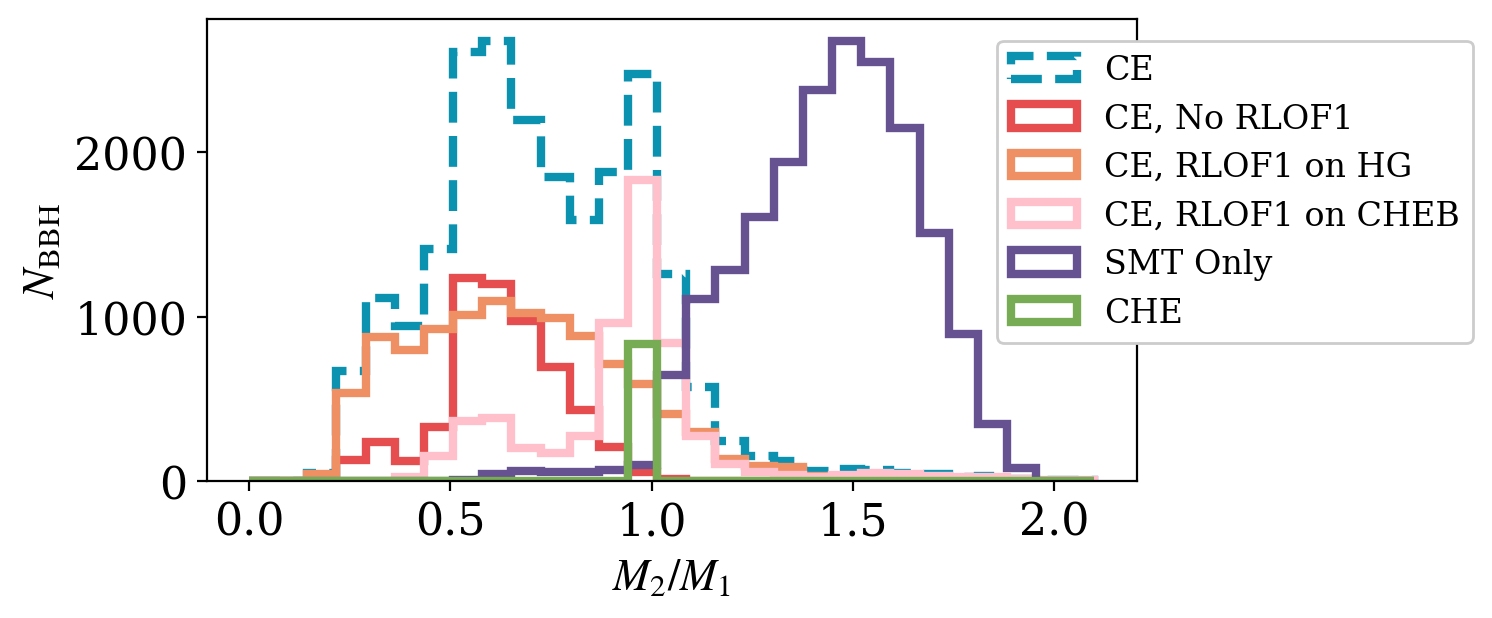

In [24]:
fig, ax = plt.subplots(ncols=1, nrows=1, figsize=(6, 3))

pop_name = 'realistic'
# pop_name = 'perfect'
dco_type = 'BBH'
pop_df = pop_dfs[pop_name]
pop_df = pop_df[pop_df[dco_type] & pop_df['Merges_Hubble_Time']]

x1 = pop_df['Mass@DCO(1)']
x2 = pop_df['Mass@DCO(2)']

# x1 = pop_df['M_max@DCO']
# x2 = pop_df['M_min@DCO']

x = x2/x1
# x = x2 / (x1+x2)

bins_x = np.linspace(0, 2.1, 30)

any_rlof = (pop_df['RLOF_Primary']==True) + (pop_df['RLOF_Secondary']==True) + (pop_df['RLOF_Both']==True)
any_ce = (pop_df['CE_Primary']==True) + (pop_df['CE_Secondary']==True) +(pop_df['CE_Both']==True)
any_che = (pop_df['CH_on_MS(1)']==True) + (pop_df['CH_on_MS(2)']==True)
smt_mask = any_rlof * (~any_ce) * (~any_che)
ce_mask = any_ce * (~any_che)

any_rlof1 = pop_df["Number_of_RLOF(SN)_Primary"] > 0
hg_rlof1_mask = pop_df["MT_Donor_Hist(SN)_Primary"].apply(lambda x: 2 in x if isinstance(x, list) else False)
cheb_rlof1_mask = pop_df["MT_Donor_Hist(SN)_Primary"].apply(lambda x: 4 in x if isinstance(x, list) else False)

ax.hist(x[ce_mask], bins=bins_x, density=False, histtype='step', lw=3, color=colorPalette['blue'], ls='--', label=r'CE')
ax.hist(x[ce_mask & ~any_rlof1], bins=bins_x, density=False, histtype='step', lw=3, color=colorPalette['red'], label=r'CE, No RLOF1')
ax.hist(x[ce_mask & any_rlof1 & hg_rlof1_mask], bins=bins_x, density=False, histtype='step', lw=3, color=colorPalette['orange'], label=r'CE, RLOF1 on HG')
ax.hist(x[ce_mask & any_rlof1 & cheb_rlof1_mask & ~hg_rlof1_mask], bins=bins_x, density=False, histtype='step', lw=3, color='pink', label=r'CE, RLOF1 on CHEB')

ax.hist(x[smt_mask], bins=bins_x, density=False, histtype='step', lw=3, color=colorPalette['violet'], label=r'SMT Only')
ax.hist(x[any_che], bins=bins_x, density=False, histtype='step', lw=3, color=colorPalette['green'], label=r'CHE')

ax.legend(fontsize=12, loc=(0.85, 0.3))
ax.set_ylabel(r'$N_{\rm BBH}$')

ax.set_xlabel('$M_2/M_1$')
# ax.set_title('BBHs that Merge in 13.7 Gyr')
# plt.tight_layout()

plt.show()

## Redshift distribution

In [8]:
pop_df.head()

,SEED,Mass@ZAMS(1),Mass@ZAMS(2),Metallicity@ZAMS(1),Omega(1),Omega(2),Eccentricity@ZAMS,SemiMajorAxis@ZAMS,CH_on_MS(1),CH_on_MS(2),Mass@DCO(1),Mass@DCO(2),SemiMajorAxis@DCO,Eccentricity@DCO,Stellar_Type(1),Stellar_Type(2),Merges_Hubble_Time,Time@DCO,Coalescence_Time,M_min@DCO,M_max@DCO,Ang_Momentum(SN)_Primary,Ang_Momentum(SN)_Secondary,Ang_Momentum(SN)_Both,MT_Donor_Hist(SN)_Primary,MT_Donor_Hist(SN)_Secondary,Mass(CP)_Primary,Mass(CP)_Secondary,Mass(CP)_Both,Mass(SN)_Primary,Mass(SN)_Secondary,Mass(SN)_Both,Mass_CO_Core@CO(SN)_Primary,Mass_CO_Core@CO(SN)_Secondary,Mass_CO_Core@CO(SN)_Both,Mass_Core@CO(SN)_Primary,Mass_Core@CO(SN)_Secondary,Mass_Core@CO(SN)_Both,Mass_Total@CO(SN)_Primary,Mass_Total@CO(SN)_Secondary,Mass_Total@CO(SN)_Both,Number_of_RLOF(SN)_Primary,Number_of_RLOF(SN)_Secondary,Number_of_RLOF(SN)_Both,Omega(SN)_Primary,Omega(SN)_Secondary,Omega(SN)_Both,Orbital_Period<SN_Primary,Orbital_Period<SN_Secondary,Orbital_Period<SN_Both,RLOF_Primary,RLOF_Secondary,RLOF_Both,Radius_Core@CO(SN)_Primary,Radius_Core@CO(SN)_Secondary,Radius_Core@CO(SN)_Both,Radius_Total@CO(SN)_Primary,Radius_Total@CO(SN)_Secondary,Radius_Total@CO(SN)_Both,SN_Orbit_Inclination_Angle_Primary,SN_Orbit_Inclination_Angle_Secondary,SN_Orbit_Inclination_Angle_Both,SN_Type(SN)_Primary,SN_Type(SN)_Secondary,SN_Type(SN)_Both,SemiMajorAxis<SN_Primary,SemiMajorAxis<SN_Secondary,SemiMajorAxis<SN_Both,Stellar_Type_Prev(SN)_Primary,Stellar_Type_Prev(SN)_Secondary,Stellar_Type_Prev(SN)_Both,Time@SN_Primary,Time@SN_Secondary,Time@SN_Both,Eccentricity<CE_Primary,Eccentricity<CE_Secondary,Eccentricity<CE_Both,Mass(1)<CE_Primary,Mass(1)<CE_Secondary,Mass(1)<CE_Both,Mass(2)<CE_Primary,Mass(2)<CE_Secondary,Mass(2)<CE_Both,SemiMajorAxis<CE_Primary,SemiMajorAxis<CE_Secondary,SemiMajorAxis<CE_Both,Stellar_Type(1)<CE_Primary,Stellar_Type(1)<CE_Secondary,Stellar_Type(1)<CE_Both,Stellar_Type(1)>CE_Primary,Stellar_Type(1)>CE_Secondary,Stellar_Type(1)>CE_Both,Stellar_Type(2)<CE_Primary,Stellar_Type(2)<CE_Secondary,Stellar_Type(2)<CE_Both,Stellar_Type(2)>CE_Primary,Stellar_Type(2)>CE_Secondary,Stellar_Type(2)>CE_Both,Time@CE_Primary,Time@CE_Secondary,Time@CE_Both,CE_Primary,CE_Secondary,CE_Both,BBH,BHNS,BNS,z_form,z_merger,a1,a2,fallback_1,fallback_2,iota1,iota2,chi_eff
2,126083,34.179102,27.917941,0.000620,0.261132,165.075173,0.721218,1.148174,False,False,10.885260,17.805314,0.049436,2.220446e-16,14,14,True,8.902238,345.353072,10.885260,17.805314,0.0,0.004573,NaN,[2],[2],49.312993,10.885260,NaN,10.885088,17.805314,NaN,8.071694,13.423413,NaN,8.071694,13.423413,NaN,10.885088,17.805314,NaN,1.0,1.0,NaN,0.0,165.075173,NaN,30.220132,0.749549,NaN,True,True,True,0.000071,0.000071,NaN,1.101499,1.342642,NaN,0.0,0.000000,NaN,1.0,1.0,NaN,0.744148,0.049436,NaN,8.0,8.0,NaN,6.604437,8.902238,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False,False,True,False,False,7.616820,5.516133,0.007580,2.643037e-01,1.0,1.0,0.0,0.000000,0.166902
3,126108,25.618102,20.381586,0.000446,0.000000,25.906309,0.370429,4.016208,False,False,9.393685,4.818462,0.061911,4.157262e-01,14,14,True,11.178367,3779.922445,4.818462,9.393685,0.0,0.000014,NaN,[4],[4],22.529402,9.393685,NaN,9.393685,4.818462,NaN,6.915085,6.294937,NaN,6.915085,6.294937,NaN,9.393685,8.592127,NaN,1.0,1.0,NaN,0.0,25.906309,NaN,883.508658,0.603508,NaN,True,True,True,0.000071,0.000071,NaN,1.051457,1.037886,NaN,0.0,0.054919,NaN,1.0,1.0,NaN,5.716232,0.036618,NaN,8.0,8.0,NaN,8.417016,11.178367,NaN,NaN,0.0,NaN,NaN,9.393685,NaN,NaN,21.842703,NaN,NaN,1271.490511,NaN,NaN,14.0,NaN,NaN,14.0,NaN,NaN,4.0,NaN,NaN,7.0,NaN,NaN,11.105812,NaN,False,True,False,True,False,False,8.239554,1.446368,0.000279,3.827138e-08,1.0,0.0,0.0,0.054919,0.000185
6,126163,45.217822,28.683535,0.007641,0.000000,1.053771,0.070984,5.530803,False,False,12.668118,10.258360,0.035784,0.000000e+00,14,14,True,7.638119,176.943405,10.258360,12.668118,0.0,0.000006,NaN,[2],[4],30.059939,12.668118,NaN,12.668118,10.258360

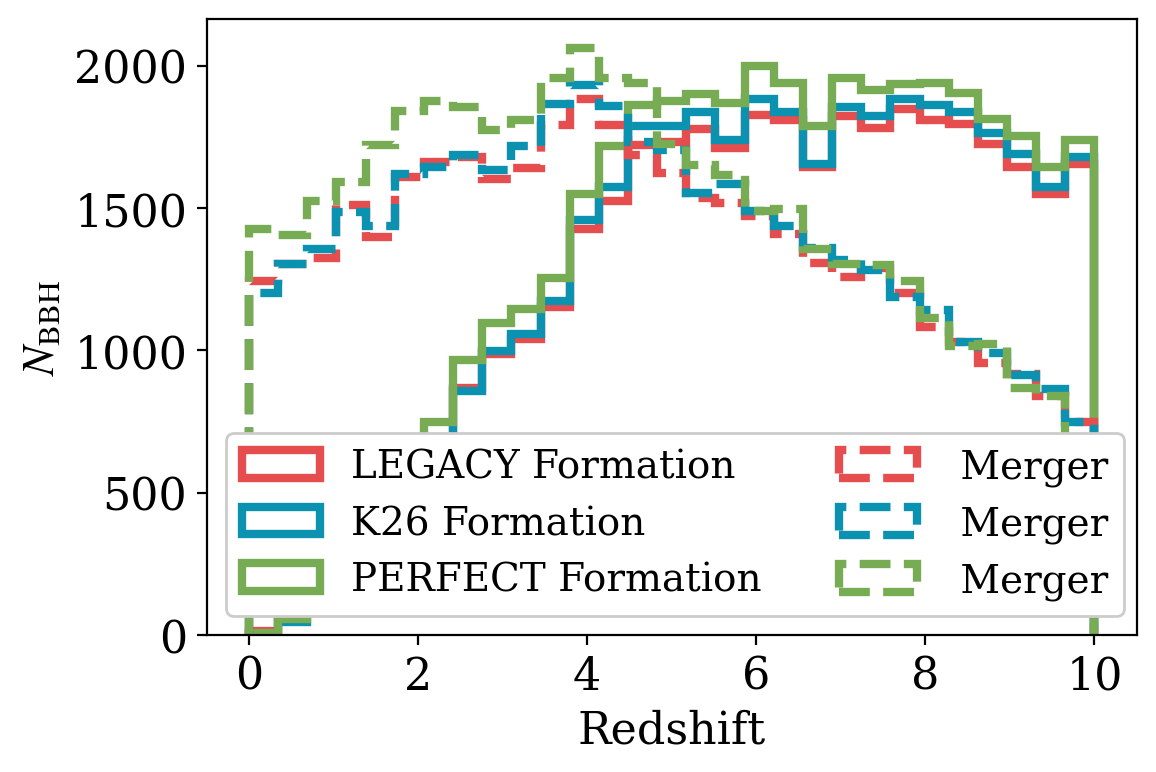

In [14]:
fig, ax = plt.subplots(ncols=1, nrows=1, figsize=(6, 4))

for pop_name in pop_names:
    pop_df = pop_dfs[pop_name]
    pop_df = pop_df[pop_df['BBH'] & pop_df['Merges_Hubble_Time']]
    ax.hist(pop_df['z_form'], bins=np.linspace(0, 10, 30), histtype='step', lw=3, label=pop_labels[pop_name]+' Formation', color=pop_colors[pop_name])

for pop_name in pop_names:
    pop_df = pop_dfs[pop_name]
    pop_df = pop_df[pop_df['BBH'] & pop_df['Merges_Hubble_Time']]    
    ax.hist(pop_df['z_merger'], bins=np.linspace(0, 10, 30), histtype='step', lw=3, ls='--', label=' Merger', color=pop_colors[pop_name])

ax.legend(fontsize=14, ncol=2)
ax.set_xlabel('Redshift')
ax.set_ylabel(r'$N_{\rm BBH}$')
plt.show()

## Mass-Period by Formation Channel

In [25]:
channel_colors = {'No MT' : colorPalette['red'], 
                  'SMT' : colorPalette['violet'], 
                  'CE' : colorPalette['blue'], 
                  'CHE' : colorPalette['green']}

channel_cmaps = {'No MT' : plt.cm.Reds,
                    'SMT' : plt.cm.Purples,
                    'CE' : plt.cm.Blues,
                    'CHE' : plt.cm.Greens}

/tmp/ipykernel_1915421/535080518.py:50: RuntimeWarning: divide by zero encountered in log10
  ax.contourf(X, Y, np.log10(hist), cmap=channel_cmaps[channel], alpha=0.7, locator=ticker.MaxNLocator(prune = 'lower'), vmin=1e-4, vmax=2.9)
/tmp/ipykernel_1915421/535080518.py:83: RuntimeWarning: divide by zero encountered in log10
  ax.contourf(X, Y, np.log10(hist), cmap=channel_cmaps[channel], alpha=0.5, locator=ticker.MaxNLocator(prune = 'lower'), vmin=1e-4, vmax=2.9, hatches=['\\\\'])


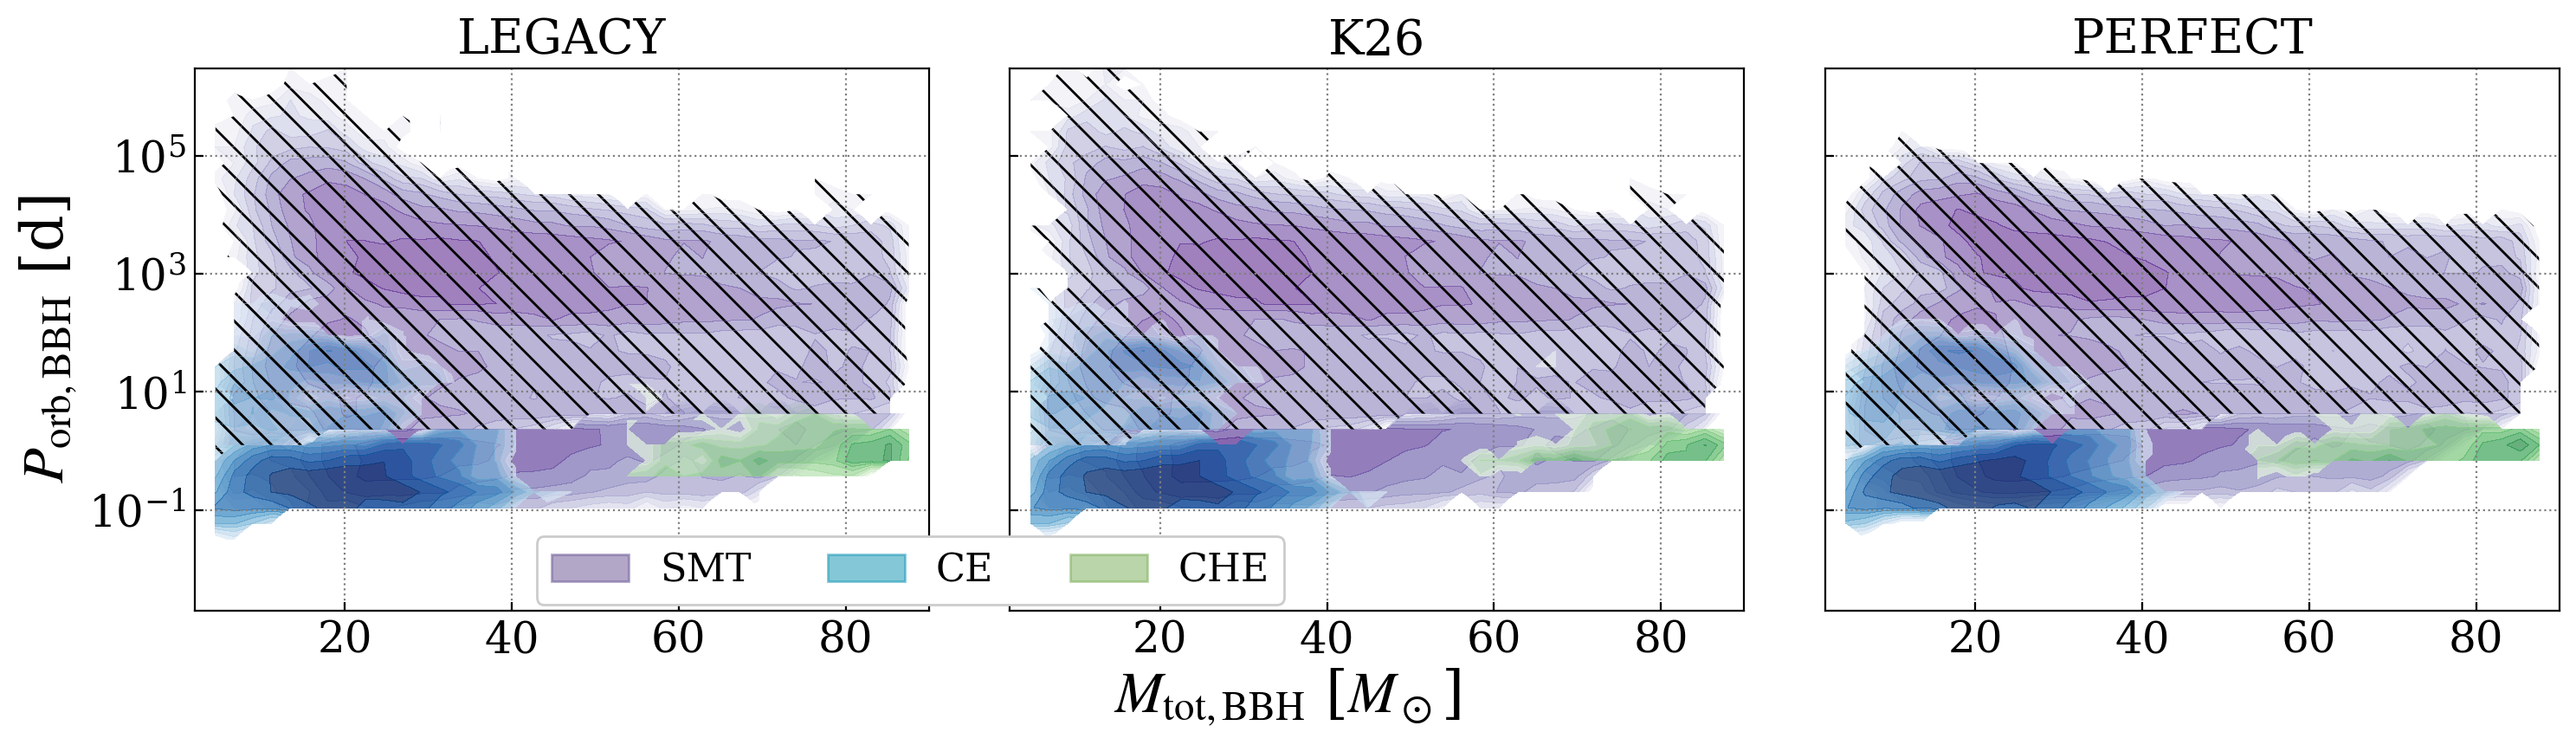

In [ ]:
import matplotlib.patches as mpatches

# channels = ['CE', 'SMT', 'CHE', 'No MT']
channels = ['SMT', 'CE', 'CHE']

dco_type = 'BBH'
fig, axes = plt.subplots(ncols=len(pop_names), figsize=(5*len(pop_names), 4), sharey=True)

for i, pop_name in enumerate(pop_names):
    ax = axes[i]
    
    # Define histogram bins
    y_bins = np.logspace(-6, 7, 50)
    x_bins = np.linspace(0, 110, 50)
    # x_bins = np.geomspace(1, 110, 50)
    # y_bins = np.linspace(min(y_vals), max(y_vals), 100)
    
    # Mask for DCO type
    pop_df = pop_dfs[pop_name]
    pop_df = pop_df[pop_df[dco_type]]
    pop_df = pop_df[pop_df['Merges_Hubble_Time']==True]
    
    rlof_mask = pop_df['RLOF_Primary'] | pop_df['RLOF_Secondary'] | pop_df['RLOF_Both']
    ce_mask = pop_df['CE_Primary'] | pop_df['CE_Secondary'] | pop_df['CE_Both']
    che_mask = pop_df['CH_on_MS(1)'] | pop_df['CH_on_MS(2)']
    smt_mask = rlof_mask & ~ce_mask & ~che_mask
    no_mt_mask = ~rlof_mask
    
    channel_masks = {}
    channel_masks['SMT'] = smt_mask
    channel_masks['CE'] = ce_mask
    channel_masks['CHE'] = che_mask
    # channel_masks['No MT'] = no_mt_mask

    for channel in channels:
        mask = channel_masks[channel]
        # Get x and y values
        x_vals = pop_df['Mass@DCO(1)'][mask] + pop_df['Mass@DCO(2)'][mask]
        omega_orb = (np.sqrt(c.G * (pop_df['Mass@DCO(1)'].values + pop_df['Mass@DCO(2)'].values) * u.M_sun / (pop_df['SemiMajorAxis@DCO'].values*u.AU)**3).to(1/u.d))
        y_vals = (2 * np.pi / omega_orb).to(u.d).value[mask]

        

        # Compute 2D histogram
        hist, x_edges, y_edges = np.histogram2d(x_vals, y_vals, bins=[x_bins, y_bins])

        # Plot contours
        X, Y = np.meshgrid(x_edges[:-1], y_edges[:-1], indexing='ij')

        ax.contourf(X, Y, np.log10(hist), cmap=channel_cmaps[channel], alpha=0.7, locator=ticker.MaxNLocator(prune = 'lower'), vmin=1e-4, vmax=2.9) 

        
    pop_df = pop_dfs[pop_name]
    pop_df = pop_df[pop_df[dco_type]]
    pop_df = pop_df[pop_df['Merges_Hubble_Time']==False]
    
    rlof_mask = pop_df['RLOF_Primary'] | pop_df['RLOF_Secondary'] | pop_df['RLOF_Both']
    ce_mask = pop_df['CE_Primary'] | pop_df['CE_Secondary'] | pop_df['CE_Both']
    che_mask = pop_df['CH_on_MS(1)'] | pop_df['CH_on_MS(2)']
    smt_mask = rlof_mask & ~ce_mask & ~che_mask
    no_mt_mask = ~rlof_mask
    
    channel_masks = {}
    channel_masks['SMT'] = smt_mask
    channel_masks['CE'] = ce_mask
    channel_masks['CHE'] = che_mask
    # channel_masks['No MT'] = no_mt_mask

    for channel in channels:
        mask = channel_masks[channel]
        # Get x and y values
        x_vals = pop_df['Mass@DCO(1)'][mask] + pop_df['Mass@DCO(2)'][mask]
        omega_orb = (np.sqrt(c.G * (pop_df['Mass@DCO(1)'].values + pop_df['Mass@DCO(2)'].values) * u.M_sun / (pop_df['SemiMajorAxis@DCO'].values*u.AU)**3).to(1/u.d))
        y_vals = (2 * np.pi / omega_orb).to(u.d).value[mask]


        # Compute 2D histogram
        hist, x_edges, y_edges = np.histogram2d(x_vals, y_vals, bins=[x_bins, y_bins])

        # Plot contours
        X, Y = np.meshgrid(x_edges[:-1], y_edges[:-1], indexing='ij')

        ax.contourf(X, Y, np.log10(hist), cmap=channel_cmaps[channel], alpha=0.5, locator=ticker.MaxNLocator(prune = 'lower'), vmin=1e-4, vmax=2.9, hatches=['\\\\']) 

    ax.set_title(pop_labels[pop_name], fontsize=20)
    # ax.set_xscale('log')
    ax.set_yscale('log')
    
    
    ax.set_xlim(2, 90)
    ax.set_ylim(2e-3, 3e6)
    
    ax.grid()

    legend_patches = [mpatches.Patch(color=channel_colors[channel], label=channel, alpha=0.5) for channel in channels]
    ax.tick_params(axis='both', direction='in', which='both')
    ax.tick_params(axis='both', labelsize=18)
        
axes[0].set_ylabel('$P_{\mathrm{orb, BBH}}$ [d]', fontsize=24)
axes[1].legend(handles=legend_patches, ncols=3, loc='lower right', fontsize=16, bbox_to_anchor=(0.4,-0.025))

fig.text(0.5, -0.04, r'$M_{\mathrm{tot, BBH}}$ [$M_\odot$]', ha='center', fontsize=24)

plt.tight_layout()
fig.subplots_adjust(wspace=0.11)
plt.show()
